In [3]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()
%run ./../ch5_LDPC_Finite_Length/getIrregularH.ipynb import getIrregularH
%run node_to_edge.ipynb import node_to_edge
%run Encode_LDPC.ipynb import Encode_LDPC

installed solvers:
['CLARABEL', 'OSQP', 'SCIP', 'SCIPY', 'SCS']
True


C:\Users\Joshua\AppData\Local\Temp\ipykernel_41736\2205991803.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L_poly[max_dv-dv] = a


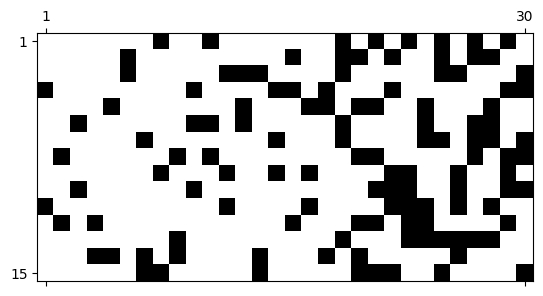

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 1]
 [1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 1 1 0 0]
 [0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1]]


In [4]:
# construct an irregular matrix
# degree distribtion
# variables node of degrees 2 3 and 6. nodes_dv contains the factors
# Lambda_i, i.e., we have 6 variable nodes of degree 2, 12 variable nodes
# of degree 3 and 12 variable nodes of degree 6

dv = np.array([2, 3, 6])
nodes_dv = np.array([6, 12, 12])

# 15 check nodes of degree 8
dc = 8
nodes_dc = np.array([15])

# normalize degree distribution
nodes_dv_norm = nodes_dv / np.sum(nodes_dv)
nodes_dc_norm = nodes_dc / np.sum(nodes_dc)

# get polynomials lambda and rho
lambdA = node_to_edge(dv, nodes_dv_norm)
rho = node_to_edge(dc, nodes_dc_norm)

H = getIrregularH(sum(nodes_dv), lambdA, rho)
plt.spy(H)
m, n = H.shape
plt.xticks([0, n-1], [1, n])
plt.yticks([0, m-1], [1, m])
plt.show()

# generate random information word
u = rng.integers(2, size=(1, 15)) - 1

# uses a slightly different representation using an upper triangular matrix
# T than in the lecture. Conceptually identical though
x = Encode_LDPC(H, u)

# verify that x is a codeword
print(np.mod(H*x,2))